In [1]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

In [2]:
def design_cic_compensator_fir(num_taps=32, R1=16, M=1, N_cic=4, fs_stage3_in=48828.125, f_passband=10000.0):
    """
    Designs an Inverse-Sinc (CIC Compensation) FIR Filter using Least Squares (firls).
    
    Parameters:
    -----------
    num_taps : int - Number of taps for Stage 3 FIR (typically 16-64)
    R1, M, N_cic : CIC parameters from Stage 1 to calculate exact inverse droop
    fs_stage3_in : Input sampling frequency to Stage 3 (48.83 kHz)
    f_passband : Desired flat passband bandwidth in Hz (e.g., 10 kHz)
    """
    nyq_in = fs_stage3_in / 2.0
    
    # 1. Frequency grid for Passband Compensation (0 to f_passband)
    f_pass = np.linspace(1e-5, f_passband, 200)
    
    # Normalized angular frequency relative to Stage 1 CIC input rate (R1 * fs_stage3_in)
    fs_cic_in = fs_stage3_in * R1
    omega_cic = 2 * np.pi * f_pass / fs_cic_in
    
    # Un-normalized CIC magnitude response: |sin(w*R*M/2) / sin(w/2)|^N
    num_cic = np.sin(omega_cic * R1 * M / 2.0)
    den_cic = np.sin(omega_cic / 2.0)
    H_cic = np.abs(num_cic / den_cic) ** N_cic
    
    # Normalized CIC Gain (DC gain = (R1*M)^N)
    H_cic_norm = H_cic / ((R1 * M) ** N_cic)
    
    # Compensation Target = 1 / H_cic_norm (Inverse Sinc)
    H_target = 1.0 / H_cic_norm
    
    # 2. Construct Bands and Desired Gain Vectors for firls
    # Passband: [0, f_passband], Stopband: [fs_stage3_in / 4, nyq_in]
    f_stop = fs_stage3_in / 4.0  # Transition start at Output Nyquist boundary
    
    bands = [0, f_passband, f_stop, nyq_in]
    
    # Sample points for passband target curve inside firls
    f_fit = np.linspace(0, f_passband, 20)
    omega_fit = 2 * np.pi * f_fit / fs_cic_in
    num_fit = np.sin(omega_fit * R1 * M / 2.0)
    den_fit = np.sin(omega_fit / 2.0)
    
    # Avoid zero division at DC
    H_fit = np.ones_like(f_fit)
    mask = omega_fit > 0
    H_fit[mask] = np.abs(num_fit[mask] / den_fit[mask]) ** N_cic / ((R1 * M) ** N_cic)
    desired_pass = 1.0 / H_fit
    
    # firls requires piecewise linear desired vector
    # Interpolate desired passband gains for firls
    desired = [desired_pass[0], desired_pass[-1], 0.0, 0.0]
    
    # Design linear-phase FIR using Least-Squares algorithm
    taps = signal.firls(num_taps, bands, desired, fs=fs_stage3_in)
    
    # Normalize Stage 3 DC gain to 0 dB
    taps = taps / np.sum(taps)
    return taps

In [13]:
def plot_stage3_compensation_fir(
    num_taps=32, 
    R1=16, M=1, N_cic=4, 
    R3=2, 
    fs_in=48828.125,      # Stage 3 Input Rate (from Stage 2 output)
    f_passband=10000.0     # Signal bandwidth to flatten
):
    """
    Plots Stage 3 FIR Compensation Filter Frequency Response and Decimation Effects.
    """
    fs_out = fs_in / R3                 # Final Rate: 24.414 kHz
    nyq_out = fs_out / 2.0              # Final Nyquist: 12.207 kHz
    
    # 1. Design Compensation Taps
    taps = design_cic_compensator_fir(num_taps, R1, M, N_cic, fs_in, f_passband)
    n_taps = np.arange(len(taps))
    
    # 2. Evaluate Frequency Response across Stage 3 Spectrum (0 to fs_in / 2)
    f_grid = np.linspace(1e-5, fs_in / 2, 5000)
    omega_grid = 2 * np.pi * f_grid / fs_in
    
    # H3(e^jw) via explicit Transfer Function evaluation
    H_stage3 = np.dot(np.exp(-1j * np.outer(omega_grid, n_taps)), taps)
    mag_stage3_db = 20 * np.log10(np.abs(H_stage3) + 1e-12)
    
    # 3. Calculate Ideal Inverse CIC curve for visual overlay comparison
    fs_cic_in = fs_in * R1
    omega_cic_grid = 2 * np.pi * f_grid / fs_cic_in
    num_c = np.sin(omega_cic_grid * R1 * M / 2.0)
    den_c = np.sin(omega_cic_grid / 2.0)
    H_cic_norm = np.abs(num_c / den_c) ** N_cic / ((R1 * M) ** N_cic)
    inverse_cic_db = 20 * np.log10((1.0 / H_cic_norm) + 1e-12)
    
    # 4. Plotting
    plt.figure(figsize=(11, 6))
    
    # FIR Response
    plt.plot(f_grid, mag_stage3_db, color='blue', linewidth=2, 
             label=f'Stage 3 FIR Response (Taps={num_taps}, R3={R3})')
    
    # Ideal Compensation Curve in Passband
    mask_pass = f_grid <= f_passband
    plt.plot(f_grid[mask_pass], inverse_cic_db[mask_pass], '--', color='orange', 
             linewidth=2, label='Ideal Inverse Sinc Target')
    
    # Final Stage 3 Nyquist Boundary
    plt.axvline(nyq_out, color='red', linestyle='--', label=f'Final Nyquist Bound ({nyq_out/1e3:.2f} kHz)')
    
    # Highlight Passband Region
    plt.axvspan(0, f_passband, color='green', alpha=0.08, label=f'Correction Passband ({f_passband/1e3:.1f} kHz)')

    # Highlight Alias Marker at fs_out
    plt.axvline(fs_out, color='purple', linestyle=':', alpha=0.7, label=f'Alias Center fs_out ({fs_out/1e3:.2f} kHz)')
    plt.axvspan(fs_out - nyq_out, min(fs_out + nyq_out, fs_in/2), color='gray', alpha=0.1, label='Alias Folded Zone')

    plt.title(f'Stage 3 Compensation FIR Filter Response & Decimation\n(Input Rate: {fs_in/1e3:.2f} kHz $\\rightarrow$ Output Rate: {fs_out/1e3:.2f} kHz | R3 = {R3})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.ylim([-80, 15])
    plt.xlim([0, fs_in / 2])
    plt.grid(True, linestyle='-', alpha=0.4)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

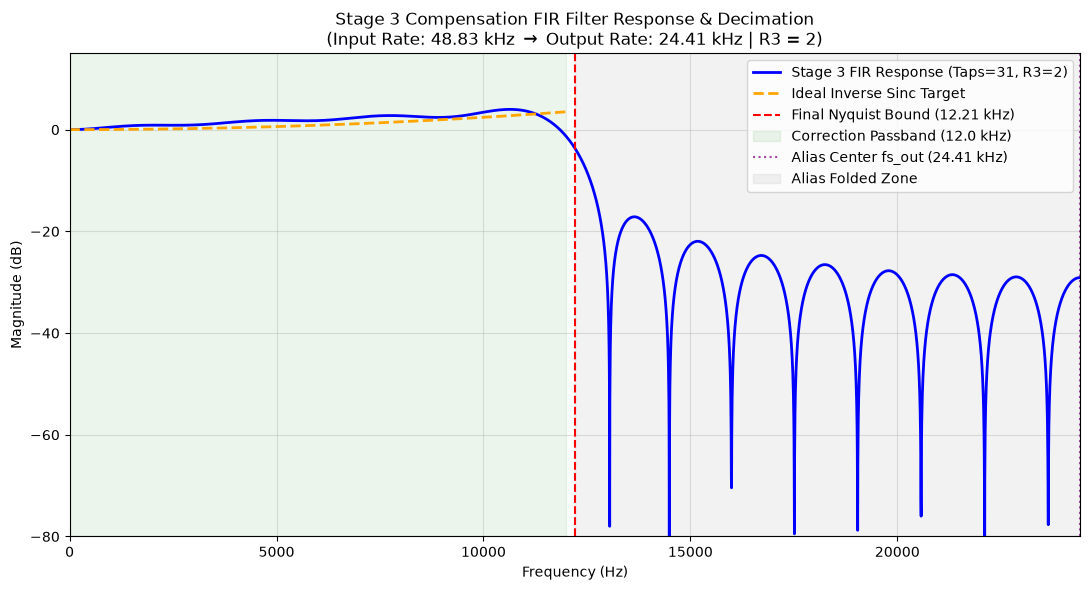

In [14]:
plot_stage3_compensation_fir(
        num_taps=31, 
        R1=16, M=1, N_cic=4, 
        R3=2, 
        fs_in=48828.125, 
        f_passband=12000.0
    )